# RL — Chapter 7 — n-step TD (Random Walk) Prediction


In [2]:
from toc import generate_toc

path = 'ch_7_ns_TD_p1_random_walk.ipynb'
generate_toc(path)

## Table of Contents

- [RL — Chapter 7 — n-step TD (Random Walk) Prediction](#rl-chapter-7-n-step-td-random-walk-prediction)
  - [Environment](#environment)
  - [n-step TD Prediction](#n-step-td-prediction)
  - [Results](#results)

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# set decimal precision for numpy arrays
np.set_printoptions(precision=1, suppress=True)


def argmax_random_tie(values: np.ndarray) -> int:
    values = np.asarray(values)
    max_value = np.max(values)
    candidates = np.flatnonzero(values == max_value)
    return int(np.random.choice(candidates))

## Environment


In [133]:
# random walk environment
class RandomWalkEnv:
    def __init__(self, n_states=5):
        self.n_states = n_states
        self.start_state = n_states // 2
        self.terminal_states = [0, n_states - 1]
        self.rewards = [0 for _ in range(n_states)]
        self.rewards[0] = -1
        self.rewards[-1] = 1

## n-step TD Prediction


In [134]:
# n-step TD
class NStepTD:
    def __init__(self, env: RandomWalkEnv, n: int, alpha: float, n_episodes: int = 100):
        self.env = env
        self.n = n
        self.alpha = alpha
        self.gamma = 1.0
        self.n_episodes = n_episodes
        self.V = np.zeros(env.n_states)
        # Analytical values for this specific setup:
        # - Unbiased random walk (left/right with prob 0.5)
        # - Reward is taken from the *next* state (env.rewards[next_state])
        # - Episode terminates upon entering a terminal state
        # Hence V(terminal)=0 and for interior states V(s)=P(hit right) - P(hit left)
        idx = np.arange(env.n_states, dtype=float)
        p_right = idx / (env.n_states - 1)
        self.true_v = 2.0 * p_right - 1.0
        self.true_v[self.env.terminal_states] = 0.0
        self.rms = 0

    def run(self):
        for _ in range(self.n_episodes):
            state = self.env.start_state
            T = float('inf')
            states = [state]
            rewards = [0]  # reward for the initial state is 0
            t = 0
            while True:
                if t < T:
                    action = np.random.choice([-1, 1])
                    next_state = states[-1] + action
                    reward = self.env.rewards[next_state]
                    states.append(next_state)
                    rewards.append(reward)
                    if next_state in self.env.terminal_states:
                        T = t + 1
                tau = t - self.n + 1
                if tau >= 0:
                    G = sum(self.gamma ** (i - tau - 1) * rewards[i] for i in range(tau + 1, min(tau + self.n, T) + 1))
                    if tau + self.n < T:
                        G += (self.gamma ** self.n) * self.V[states[tau + self.n]]
                    state_to_update = states[tau]
                    if state_to_update not in self.env.terminal_states:
                        self.V[state_to_update] += self.alpha * (G - self.V[state_to_update])
                if tau == T - 1:
                    break
                t += 1

        self.rms = self.calculate_rms_error()

    def calculate_rms_error(self):
        return np.sqrt(np.mean((self.V[1:-1] - self.true_v[1:-1]) ** 2))

## Results


In [135]:
#
env = RandomWalkEnv(n_states=19)
n_step_td = NStepTD(env, n=4, alpha=0.5, n_episodes=100)
n_step_td.run()
print("RMS Error:", n_step_td.rms)

RMS Error: 0.22620811836926516


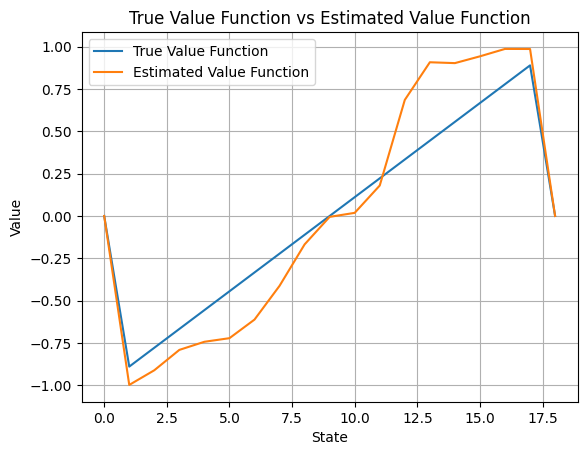

In [136]:
# plot true value function and estimated value function
plt.plot(n_step_td.true_v, label='True Value Function')
plt.plot(n_step_td.V, label='Estimated Value Function')
plt.xlabel('State')
plt.ylabel('Value')
plt.title('True Value Function vs Estimated Value Function')
plt.legend()
plt.grid()
plt.show()

In [137]:
#
alphas = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
ns = [1, 2, 4, 8, 16, 32, 64]
rms_errors = np.zeros((len(ns), len(alphas)))
env = RandomWalkEnv(n_states=19)
for j, n_step in enumerate(ns):
    for i, alpha in enumerate(alphas):
        for _ in range(100):
            n_step_td = NStepTD(env, n=n_step, alpha=alpha, n_episodes=10)
            n_step_td.run()
            rms_errors[j, i] += n_step_td.rms
        rms_errors[j, i] /= 100

In [138]:
print(rms_errors)

[[0.5 0.5 0.4 0.3 0.2 0.2 0.2 0.4]
 [0.5 0.4 0.3 0.2 0.2 0.4 0.4 0.6]
 [0.5 0.3 0.2 0.2 0.3 0.5 0.5 0.6]
 [0.5 0.2 0.2 0.4 0.5 0.5 0.6 0.7]
 [0.5 0.2 0.3 0.5 0.5 0.6 0.7 0.7]
 [0.5 0.3 0.5 0.6 0.6 0.7 0.7 0.7]
 [0.5 0.4 0.5 0.7 0.7 0.8 0.7 0.8]]


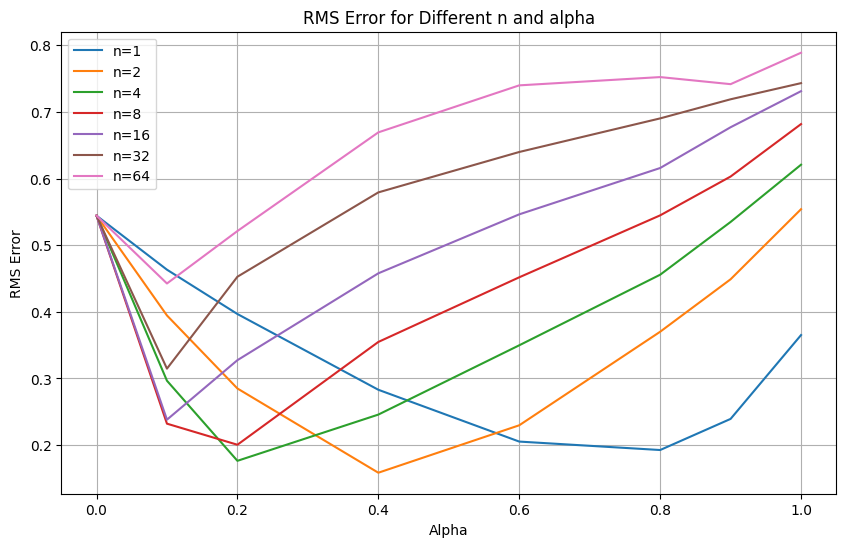

In [139]:
# plotting
plt.figure(figsize=(10, 6))
for i, n in enumerate(ns):
    plt.plot(alphas, rms_errors[i], label=f'n={n}')
plt.xlabel('Alpha')
plt.ylabel('RMS Error')
plt.title('RMS Error for Different n and alpha')
plt.legend()
plt.grid()
plt.show()